# Assignment: Vietnamese News Classification

**Task:** single-label classification of VnExpress articles into `the-thao`, `kinh-doanh`, `khoa-hoc`, and `giai-tri` using traditional NLP (PyVi, TF-IDF) and sklearn models (MultinomialNB, Logistic Regression, LinearSVC).

**Table:** `raw_vnexpress_articles.csv` with `raw_content` and `category`. Modeling uses `clean_content` after `preprocess_vietnamese_text()`.

```text
VnExpress.net → CSV → preprocess + filter → EDA (style, stopwords, keywords, bigrams, cosine)
    → TF-IDF unigrams+bigrams (train-only Pipeline) → classify → report + confusion matrix
```

## Setup
This section installs the necessary Python libraries required for Vietnamese text processing (`pyvi`) and data visualization (`plotly`).

In [23]:
!pip install pyvi
!pip install plotly

## Data Collection
The scraping pipeline extracts full news articles from VnExpress via a robust two-stage workflow:

URL Harvesting: Traverses paginated category listings to collect valid article links while filtering out non-text entries (e.g., videos, podcasts).

Body Extraction: Visits each URL to parse the complete article text (<p class="Normal">), pruning corrupted or very short records (< 80 words).

Fault Tolerance: Incorporates request pacing (rate-limiting), exponential backoff retries for transient network drops, and periodic checkpoint saving to ensure seamless recovery without data loss.

In [24]:
import os
import time
from bs4 import BeautifulSoup
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML,"
        " like Gecko) Chrome/124.0.0.0 Safari/537.36"
    )
}

session = requests.Session()
retries = Retry(
    total=3, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504]
)
session.mount("https://", HTTPAdapter(max_retries=retries))

categories = {
    "the-thao": "https://vnexpress.net/the-thao",
    "kinh-doanh": "https://vnexpress.net/kinh-doanh",
    "khoa-hoc": "https://vnexpress.net/khoa-hoc-cong-nghe",
    "giai-tri": "https://vnexpress.net/giai-tri",
}

CSV_FILE = "raw_vnexpress_articles.csv"
TARGET_PER_CATEGORY = 550

def get_raw_content(article_url):
  try:
    resp = session.get(article_url, headers=headers, timeout=10)
    if resp.status_code != 200:
      return ""

    soup = BeautifulSoup(resp.text, "html.parser")
    paras = soup.find_all("p", class_="Normal")
    if not paras:
      return ""

    return "\n".join([p.get_text() for p in paras])
  except Exception:
    return ""


articles = []
saved_urls = set()

if os.path.exists(CSV_FILE):
  df_existing = pd.read_csv(CSV_FILE)
  saved_urls = set(df_existing["url"].dropna().tolist())
  articles = df_existing.to_dict("records")
  print(f"Loaded {len(articles)} existing articles from {CSV_FILE}.")

for label, base_url in categories.items():
  print(f"\n>>> Collecting category: {label.upper()}")
  current_cat_count = sum(1 for a in articles if a.get("category") == label)

  if current_cat_count >= TARGET_PER_CATEGORY:
    print(f"Category {label} already has {current_cat_count} articles, skipping.")
    continue

  for p in range(1, 50):
    if current_cat_count >= TARGET_PER_CATEGORY:
      break

    list_url = f"{base_url}-p{p}"
    try:
      resp = session.get(list_url, headers=headers, timeout=10)
      if resp.status_code != 200:
        continue

      soup = BeautifulSoup(resp.text, "html.parser")
      items = soup.find_all("article", class_="item-news")

      for item in items:
        if current_cat_count >= TARGET_PER_CATEGORY:
          break

        title_tag = item.find(class_="title-news")
        if not title_tag:
          continue

        link_tag = title_tag.find("a")
        if not link_tag or not link_tag.get("href"):
          continue

        art_url = link_tag["href"]

        if (
            art_url in saved_urls
            or not art_url.startswith("https://vnexpress.net/")
            or "/video/" in art_url
            or "/podcast/" in art_url
        ):
          continue

        raw_text = get_raw_content(art_url)

        if len(raw_text.strip()) > 100:
          record = {"url": art_url, "raw_content": raw_text, "category": label}
          articles.append(record)
          saved_urls.add(art_url)
          current_cat_count += 1

          if len(articles) % 50 == 0:
            pd.DataFrame(articles).to_csv(
                CSV_FILE, index=False, encoding="utf-8-sig"
            )
            print(
                f"[{label}] Checkpoint saved: {current_cat_count}/{TARGET_PER_CATEGORY}"
                f" articles (Total: {len(articles)})"
            )

        time.sleep(0.3)

      time.sleep(0.5)
    except Exception as e:
      print(f"Error at {list_url}: {e}")
      time.sleep(2)
      continue

df_final = pd.DataFrame(articles)
df_final.to_csv(CSV_FILE, index=False, encoding="utf-8-sig")

print(f"\n=========================================")
print(f"COLLECTION COMPLETE: {len(df_final)} raw articles.")
print("Category distribution:")
print(df_final["category"].value_counts())
print(f"Saved to: {CSV_FILE}")
print(f"=========================================")

Loaded 2200 existing articles from raw_vnexpress_articles.csv.

>>> Collecting category: THE-THAO
Category the-thao already has 550 articles, skipping.

>>> Collecting category: KINH-DOANH
Category kinh-doanh already has 550 articles, skipping.

>>> Collecting category: KHOA-HOC
Category khoa-hoc already has 550 articles, skipping.

>>> Collecting category: GIAI-TRI
Category giai-tri already has 550 articles, skipping.

COLLECTION COMPLETE: 2200 raw articles.
Category distribution:
category
the-thao      550
kinh-doanh    550
khoa-hoc      550
giai-tri      550
Name: count, dtype: int64
Saved to: raw_vnexpress_articles.csv


## Data Preprocessing
A structured preprocessing pipeline to clean and prepare raw article text for downstream machine learning tasks:

* Noise Removal & Normalization: Strips URLs, email addresses, metadata notes, special characters, and digits, followed by text lowercasing.

* Vietnamese Word Segmentation: Applies ViTokenizer (from PyVi) to segment multi-syllable Vietnamese compound words into unified tokens.

* Filtering & Categorical Encoding: Prunes short articles to maintain corpus depth and encodes categorical topic labels into numeric identifiers via LabelEncoder.

In [25]:
import re
import unicodedata
import pandas as pd
from pyvi import ViTokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('raw_vnexpress_articles.csv')

def preprocess_vietnamese_text(text):
  if not isinstance(text, str) or not text.strip():
    return ''

  text = unicodedata.normalize('NFC', text)

  text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
  text = re.sub(r'\S+@\S+', ' ', text)

  text = re.sub(r'(ảnh|theo|nguồn):\s*[\w\s\.-]+$', ' ', text, flags=re.IGNORECASE)

  text = re.sub(r'^[A-ZÀ-Ỹa-zà-ỹ\s]+[-–—]\s*', '', text)

  text = text.lower()

  text = re.sub(r'[^\w\s]', ' ', text)
  text = re.sub(r'\d+', ' ', text)

  text = re.sub(r'\s+', ' ', text).strip()

  text = ViTokenizer.tokenize(text)

  return text

df['clean_content'] = df['raw_content'].apply(preprocess_vietnamese_text)

df = df[df['clean_content'].str.split().str.len() > 30].reset_index(drop=True)

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['category'])

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_content'],
    df['category'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_id'],
)

print('=== HOÀN TẤT TIỀN XỬ LÝ ===')
print(f'Số lượng mẫu hợp lệ: {len(df)}')
print('Category counts after filtering:')
print(df['category'].value_counts())
print(f'Kích thước tập Train: {len(X_train)} | Tập Test: {len(X_test)}')
print('Train category counts:')
print(y_train.value_counts())
print('Test category counts:')
print(y_test.value_counts())
print(f'Bản đồ mã hóa nhãn: {dict(zip(le.classes_, le.transform(le.classes_)))}')

=== HOÀN TẤT TIỀN XỬ LÝ ===
Số lượng mẫu hợp lệ: 2199
Kích thước tập Train: 1759 | Tập Test: 440
Bản đồ mã hóa nhãn: {'giai-tri': np.int64(0), 'khoa-hoc': np.int64(1), 'kinh-doanh': np.int64(2), 'the-thao': np.int64(3)}


## Exploratory Data Analysis (EDA)
An in-depth surface-level statistical analysis to capture distinctive writing styles across news categories:

* Textual Feature Extraction: Computes article-level metrics, including character and word counts, average word length, digit frequencies, and uppercase acronym counts.

* Cross-Category Comparative Profiling: Visualizes distribution densities, central tendencies, and variance across target classes to uncover informative statistical signals prior to model training.

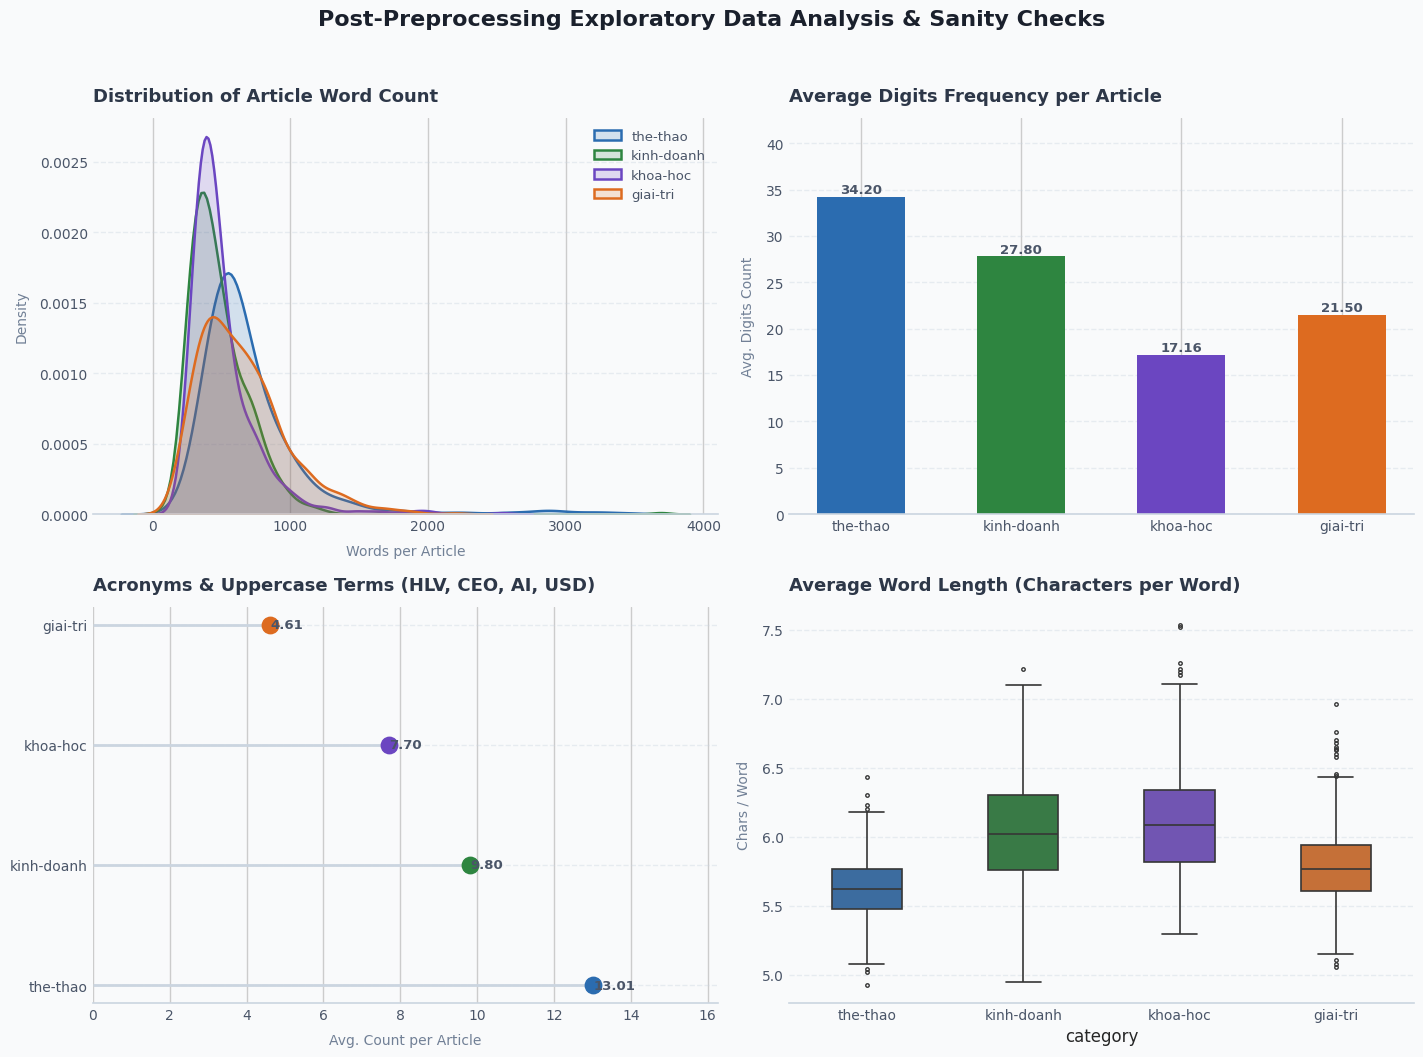

In [26]:
import re
import unicodedata
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def clean_for_stats(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'(ảnh|theo|nguồn):\s*[\w\s\.-]+$', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'^[A-ZÀ-Ỹa-zà-ỹ\s]+[-–—]\s*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Extract attributes
df['stats_content'] = df['raw_content'].apply(clean_for_stats)
df["char_count"] = df["clean_content"].apply(len)
df["word_count"] = df["clean_content"].apply(lambda x: len(x.split()))
df["avg_word_length"] = df["char_count"] / df["word_count"]
df["digits_count"] = df["stats_content"].apply(lambda x: len(re.findall(r"\d+", x)))
df["upper_words_count"] = df["stats_content"].apply(
    lambda x: len([w for w in x.split() if w.isupper() and len(w) > 1])
)

BG_COLOR = '#F9FAFB'
cats = ['the-thao', 'kinh-doanh', 'khoa-hoc', 'giai-tri']
palette = {
    'the-thao': '#2B6CB0',
    'kinh-doanh': '#2E8540',
    'khoa-hoc': '#6B46C1',
    'giai-tri': '#DD6B20'
}

fig, axes = plt.subplots(2, 2, figsize=(15, 11), facecolor=BG_COLOR)

def style_ax(ax):
    ax.set_facecolor(BG_COLOR)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#CBD5E0')
    ax.spines['bottom'].set_linewidth(1.2)
    ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CBD5E0')
    ax.tick_params(axis='both', which='both', length=0, labelsize=10, colors='#4A5568')

style_ax(axes[0, 0])
for cat in cats:
    subset = df[df['category'] == cat]
    sns.kdeplot(
        subset['word_count'], ax=axes[0, 0], label=cat,
        fill=True, color=palette[cat], alpha=0.18, linewidth=1.8
    )
axes[0, 0].set_title('Distribution of Article Word Count', loc='left', fontsize=13, fontweight='bold', color='#2D3748', pad=12)
axes[0, 0].set_xlabel('Words per Article', fontsize=10, color='#718096', labelpad=8)
axes[0, 0].set_ylabel('Density', fontsize=10, color='#718096', labelpad=8)
axes[0, 0].legend(frameon=False, fontsize=9.5, labelcolor='#4A5568')

style_ax(axes[0, 1])
means_digit = df.groupby('category')['digits_count'].mean().reindex(cats)
bars2 = axes[0, 1].bar(cats, means_digit, color=[palette[c] for c in cats], width=0.55, edgecolor='none')
axes[0, 1].set_title('Average Digits Frequency per Article', loc='left', fontsize=13, fontweight='bold', color='#2D3748', pad=12)
axes[0, 1].set_ylabel('Avg. Digits Count', fontsize=10, color='#718096', labelpad=8)
for bar in bars2:
    yval = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#4A5568')
axes[0, 1].set_ylim(0, max(means_digit) * 1.25)

style_ax(axes[1, 0])
means_upper = df.groupby('category')['upper_words_count'].mean().reindex(cats)
axes[1, 0].hlines(y=cats, xmin=0, xmax=means_upper, color='#CBD5E0', linewidth=2, zorder=1)
for cat in cats:
    axes[1, 0].scatter(means_upper[cat], cat, color=palette[cat], s=140, zorder=2)
    axes[1, 0].text(means_upper[cat] + 0.02, cat, f'{means_upper[cat]:.2f}', va='center', fontsize=9.5, fontweight='bold', color='#4A5568')
axes[1, 0].set_title('Acronyms & Uppercase Terms (HLV, CEO, AI, USD)', loc='left', fontsize=13, fontweight='bold', color='#2D3748', pad=12)
axes[1, 0].set_xlabel('Avg. Count per Article', fontsize=10, color='#718096', labelpad=8)
axes[1, 0].set_xlim(0, max(means_upper) * 1.25)

style_ax(axes[1, 1])
sns.boxplot(
    data=df, x='category', y='avg_word_length', ax=axes[1, 1],
    palette=palette, order=cats, width=0.45, fliersize=2.5, linewidth=1.2,
    hue='category', legend=False
)
axes[1, 1].set_title('Average Word Length (Characters per Word)', loc='left', fontsize=13, fontweight='bold', color='#2D3748', pad=12)
axes[1, 1].set_ylabel('Chars / Word', fontsize=10, color='#718096', labelpad=8)

fig.suptitle('Post-Preprocessing Exploratory Data Analysis & Sanity Checks', fontsize=16, fontweight='bold', color='#1A202C', y=0.98)

plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.96])
plt.show()

### Vietnamese Stopwords Analysis
An empirical analysis assessing the density and distribution of functional stopwords across the corpus:

* Frequency Ranking & Visualization: Identifies and ranks the top 20 most frequent Vietnamese stopwords, displayed via a clean horizontal bar chart.

* Corpus-Level Quantification: Measures total token counts, aggregate stopword volume, and the overall stopword ratio to justify vocabulary pruning prior to text vectorization.

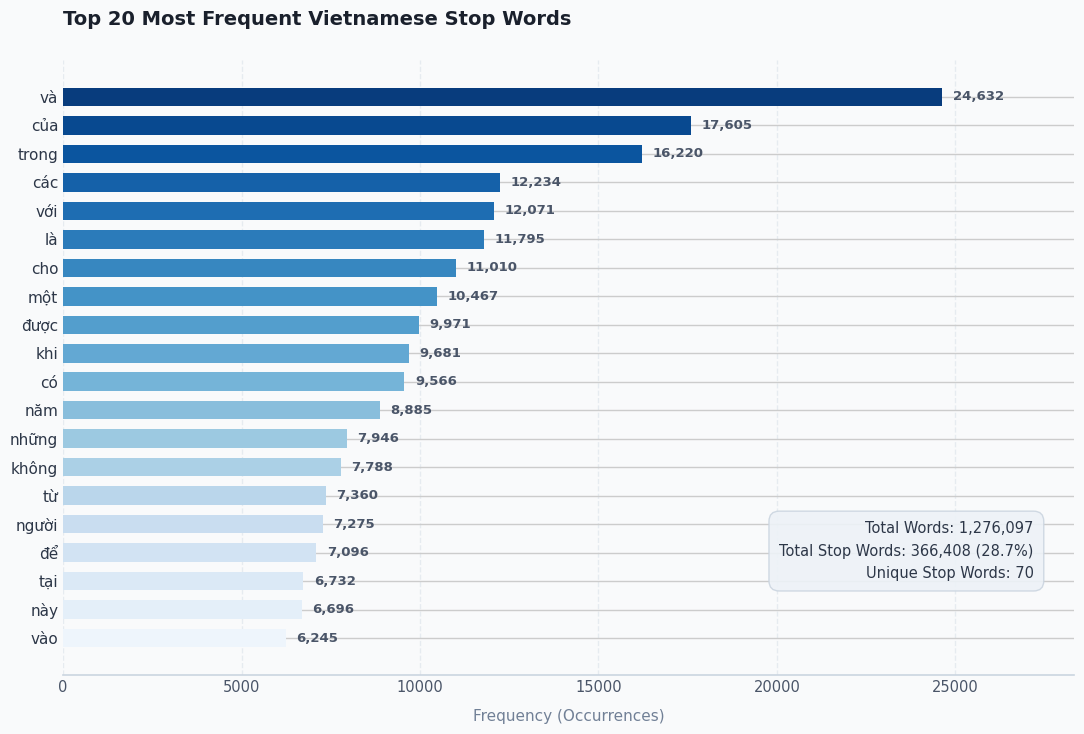

In [27]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

all_text = ' '.join(df['clean_content'].dropna()).lower()
all_words = re.findall(r'(?u)\b[a-zà-ỹA-ZÀ-Ỹ_]{2,}\b', all_text)

stop_word_counts = Counter(
    [word for word in all_words if word in vietnamese_stopwords]
)
top_stop_words = stop_word_counts.most_common(20)

words = [word for word, count in top_stop_words]
counts = [count for word, count in top_stop_words]

total_words = len(all_words)
total_stop_words = sum(stop_word_counts.values())
ratio = (total_stop_words / total_words) * 100 if total_words > 0 else 0

BG_COLOR = '#F9FAFB'
fig, ax = plt.subplots(figsize=(11, 7.5), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

for spine in ['top', 'right', 'left']:
  ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#CBD5E0')
ax.spines['bottom'].set_linewidth(1.2)
ax.grid(axis='x', linestyle='--', alpha=0.4, color='#CBD5E0')
ax.tick_params(
    axis='both', which='both', length=0, labelsize=10.5, colors='#4A5568'
)

y_pos = range(len(words))
colors = sns.color_palette('Blues_r', len(words))
bars = ax.barh(y_pos, counts, color=colors, height=0.65, edgecolor='none')

ax.set_yticks(y_pos)
ax.set_yticklabels(words, fontsize=11, fontweight='medium', color='#2D3748')
ax.invert_yaxis()

for bar, count in zip(bars, counts):
  ax.text(
      count + max(counts) * 0.012,
      bar.get_y() + bar.get_height() / 2.0,
      f'{count:,}',
      va='center',
      ha='left',
      fontsize=9.5,
      fontweight='bold',
      color='#4A5568',
  )

ax.set_xlim(0, max(counts) * 1.15)
ax.set_xlabel(
    'Frequency (Occurrences)', fontsize=11, color='#718096', labelpad=10
)
ax.set_ylabel('')

ax.set_title(
    'Top 20 Most Frequent Vietnamese Stop Words',
    loc='left',
    fontsize=14,
    fontweight='bold',
    color='#1A202C',
    pad=25,
)

stat_text = (
    f'Total Words: {total_words:,}\n'
    f'Total Stop Words: {total_stop_words:,} ({ratio:.1f}%)\n'
    f'Unique Stop Words: {len(stop_word_counts)}'
)

ax.text(
    0.96,
    0.25,
    stat_text,
    transform=ax.transAxes,
    fontsize=10.5,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round,pad=0.7',
        facecolor='#EDF2F7',
        edgecolor='#CBD5E0',
        alpha=0.9,
    ),
    color='#2D3748',
    linespacing=1.6,
)

plt.tight_layout()
plt.show()

### Word-count Analysis
An exploratory analysis capturing the salient lexical signatures unique to each news topic:

* Core Vocabulary Extraction: Prunes non-informative functional stopwords to isolate the most frequent semantic tokens across individual classes.

* Comparative Lexical Inspection: Ranks and visualizes the top 15 distinctive terms per domain using coordinated horizontal bar charts to highlight domain-specific vocabulary.

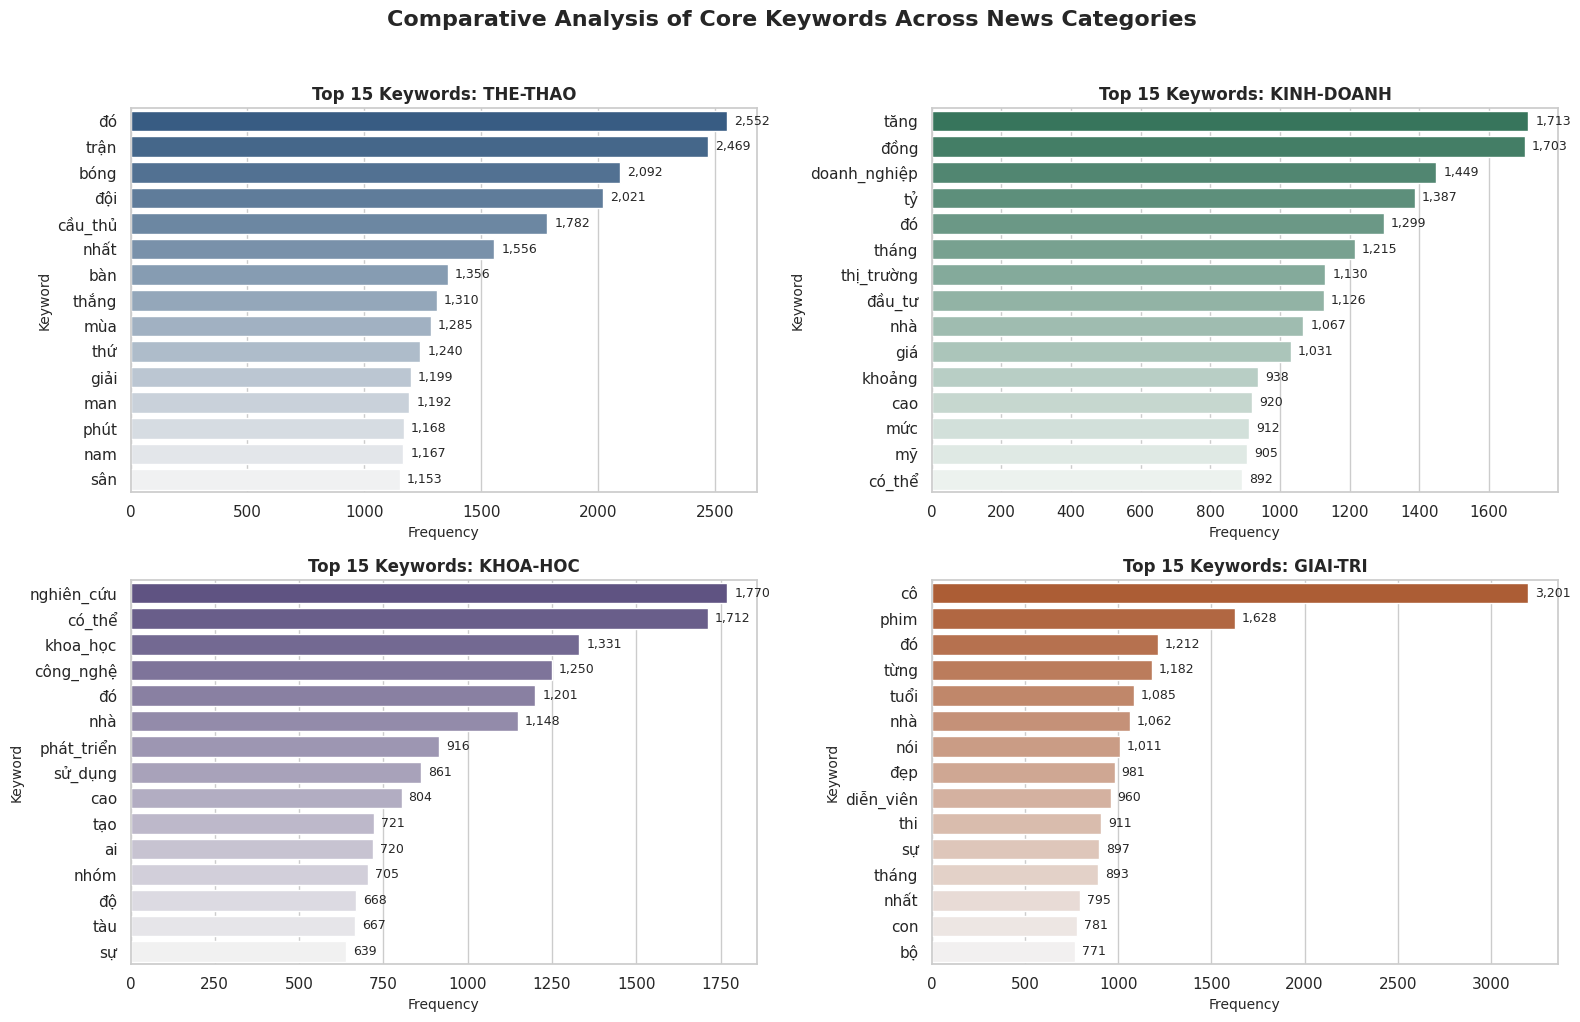

In [28]:
import math
import re
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

categories = df['category'].unique()
n_cats = len(categories)

n_cols = 2
n_rows = math.ceil(n_cats / n_cols)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()  # Flatten the axes array for easy iteration

colors = ['#2b5c8f', '#2d7f5e', '#5b4b8a', '#c05621', '#805ad5']

for idx, cat in enumerate(categories):
  ax = axes[idx]
  cat_df = df[df['category'] == cat]
  all_text = ' '.join(cat_df['clean_content'].dropna()).lower()

  words = re.findall(r'(?u)\b[a-zà-ỹA-ZÀ-Ỹ_]{2,}\b', all_text)

  words = [w for w in words if w not in vietnamese_stopwords]
  word_counts = Counter(words).most_common(15)

  words_list = [w for w, c in word_counts]
  counts_list = [c for w, c in word_counts]
  df_cat = pd.DataFrame({'Keyword': words_list, 'Frequency': counts_list})

  selected_color = colors[idx % len(colors)]
  cat_palette = sns.light_palette(selected_color, n_colors=15, reverse=True)

  sns.barplot(
      data=df_cat,
      x='Frequency',
      y='Keyword',
      ax=ax,
      palette=cat_palette,
      hue='Keyword',
      legend=False
  )

  ax.set_title(f'Top 15 Keywords: {cat.upper()}', fontweight='bold', fontsize=12)
  ax.set_xlabel('Frequency', fontsize=10)
  ax.set_ylabel('Keyword', fontsize=10)

  for p in ax.patches:
      width = p.get_width()
      ax.annotate(f'{int(width):,}',
                  (width, p.get_y() + p.get_height() / 2.),
                  ha='left', va='center',
                  xytext=(5, 0),
                  textcoords='offset points',
                  fontsize=9)

for idx in range(n_cats, len(axes)):
  fig.delaxes(axes[idx])

plt.suptitle('Comparative Analysis of Core Keywords Across News Categories', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Bigrams Analysis
An advanced n-gram analysis aimed at capturing context-rich compound concepts and entity pairs across news domains:

* TF-IDF Weighting Scheme: Employs TF-IDF scoring on segmented texts to quantify the statistical significance and distinctiveness of two-word sequences (bigrams).

* Salient Phrase Visualization: Highlights the top 15 highest-ranked bigrams per category using comparative horizontal bar charts, showcasing the primary multi-word terminology defining each domain.

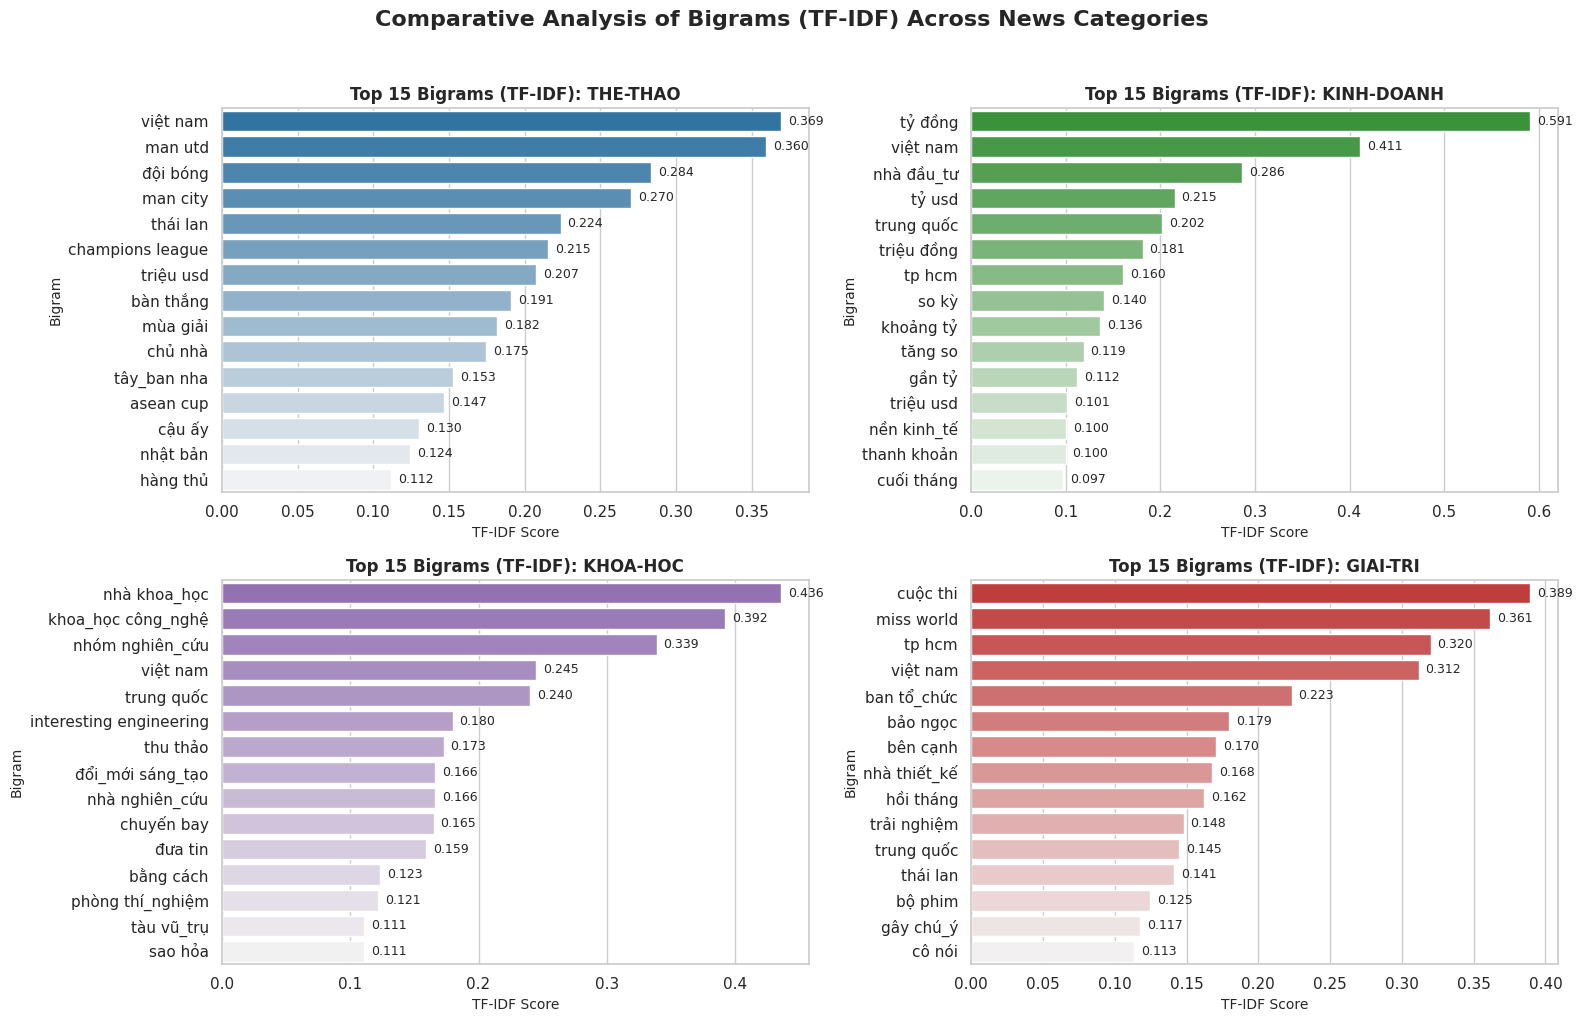

In [29]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

categories = df['category'].unique()
n_cats = len(categories)

n_cols = 2
n_rows = math.ceil(n_cats / n_cols)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

colors = ['#1f77b4', '#2ca02c', '#9467bd', '#d62728']

for idx, cat in enumerate(categories):
  ax = axes[idx]
  cat_df = df[df['category'] == cat]
  combined_text = ' '.join(cat_df['clean_content'].dropna().values).lower()

  vectorizer = TfidfVectorizer(
      ngram_range=(2, 2),
      token_pattern=r'(?u)\b[a-zà-ỹA-ZÀ-Ỹ_]{2,}\b',
      stop_words=list(vietnamese_stopwords),
      max_features=50,
  )
  tfidf_matrix = vectorizer.fit_transform([combined_text])

  feature_names = vectorizer.get_feature_names_out()
  tfidf_scores = tfidf_matrix.toarray()[0]

  top_indices = tfidf_scores.argsort()[-15:][::-1]
  top_bigrams = [feature_names[i] for i in top_indices]
  top_scores = [tfidf_scores[i] for i in top_indices]

  df_cat = pd.DataFrame({'Bigram': top_bigrams, 'TF-IDF Score': top_scores})

  selected_color = colors[idx % len(colors)]
  cat_palette = sns.light_palette(selected_color, n_colors=15, reverse=True)

  sns.barplot(
      data=df_cat,
      x='TF-IDF Score',
      y='Bigram',
      ax=ax,
      palette=cat_palette,
      hue='Bigram',
      legend=False
  )

  ax.set_title(f'Top 15 Bigrams (TF-IDF): {cat.upper()}', fontweight='bold', fontsize=12)
  ax.set_xlabel('TF-IDF Score', fontsize=10)
  ax.set_ylabel('Bigram', fontsize=10)

  for p in ax.patches:
      width = p.get_width()
      ax.annotate(f'{width:.3f}',
                  (width, p.get_y() + p.get_height() / 2.),
                  ha='left', va='center',
                  xytext=(5, 0),
                  textcoords='offset points',
                  fontsize=9)

for idx in range(n_cats, len(axes)):
  fig.delaxes(axes[idx])

plt.suptitle('Comparative Analysis of Bigrams (TF-IDF) Across News Categories', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

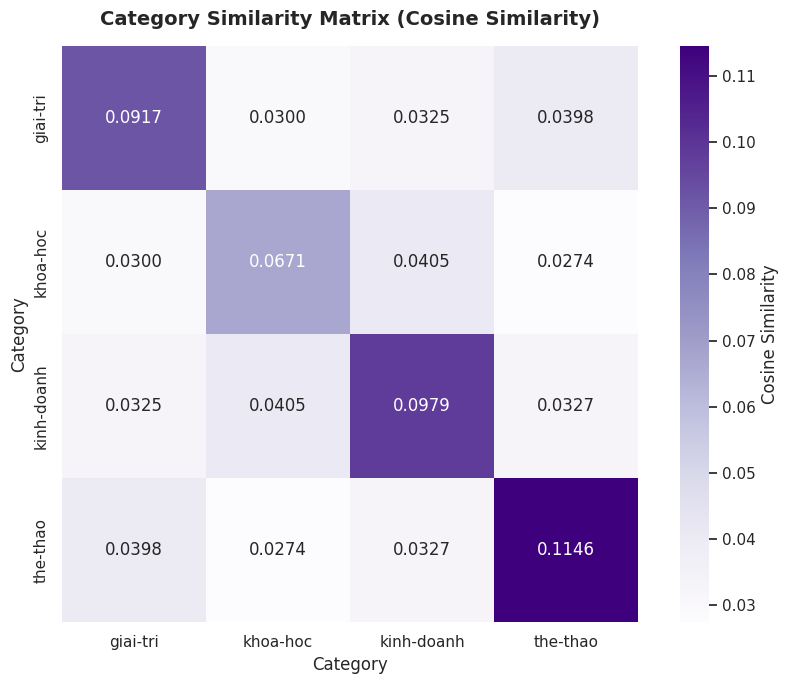

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

categories = sorted(df['category'].unique())

vectorizer = TfidfVectorizer(
    max_features=5000,
    token_pattern=r'(?u)\b[a-zà-ỹA-ZÀ-Ỹ_]{2,}\b',
    stop_words=list(vietnamese_stopwords),
)
tfidf_matrix = vectorizer.fit_transform(df['clean_content'])

n_cats = len(categories)
similarity_matrix = np.zeros((n_cats, n_cats))

for i, cat1 in enumerate(categories):
  cat1_indices = df[df['category'] == cat1].index
  cat1_vectors = tfidf_matrix[cat1_indices]

  for j, cat2 in enumerate(categories):
    cat2_indices = df[df['category'] == cat2].index
    cat2_vectors = tfidf_matrix[cat2_indices]

    pairwise_sim = cosine_similarity(cat1_vectors, cat2_vectors)

    similarity_matrix[i, j] = np.mean(pairwise_sim)

plt.figure(figsize=(9, 7))
sns.set_theme(style="white")

ax = sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt='.4f',
    cmap='Purples',
    xticklabels=categories,
    yticklabels=categories,
    square=True,
    cbar_kws={'label': 'Cosine Similarity'}
)

plt.title('Category Similarity Matrix (Cosine Similarity)', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

## Model Training and Evaluation

Reuse the stratified 80/20 split created after preprocessing (`X_train`, `X_test`, `y_train`, `y_test`). Do not split again.

Each model is a sklearn `Pipeline`: `TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words=vietnamese_stopwords)` then `MultinomialNB`, `LogisticRegression(max_iter=1000, C=1.0)`, or `LinearSVC(dual='auto', C=1.0)`. TF-IDF is fitted on the training fold only.

Evaluation: `classification_report` (precision, recall, F1, support), a consolidated comparison table, confusion matrices, and LinearSVC misclassified snippets.

========== MultinomialNB ==========
              precision    recall  f1-score   support

    giai-tri     0.9909    0.9909    0.9909       110
    khoa-hoc     0.9464    0.9636    0.9550       110
  kinh-doanh     0.9636    0.9636    0.9636       110
    the-thao     1.0000    0.9818    0.9908       110

    accuracy                         0.9750       440
   macro avg     0.9752    0.9750    0.9751       440
weighted avg     0.9752    0.9750    0.9751       440

========== LogisticRegression ==========
              precision    recall  f1-score   support

    giai-tri     0.9909    0.9909    0.9909       110
    khoa-hoc     0.9474    0.9818    0.9643       110
  kinh-doanh     0.9815    0.9636    0.9725       110
    the-thao     1.0000    0.9818    0.9908       110

    accuracy                         0.9795       440
   macro avg     0.9799    0.9795    0.9796       440
weighted avg     0.9799    0.9795    0.9796       440

========== LinearSVC ==========
              precisi

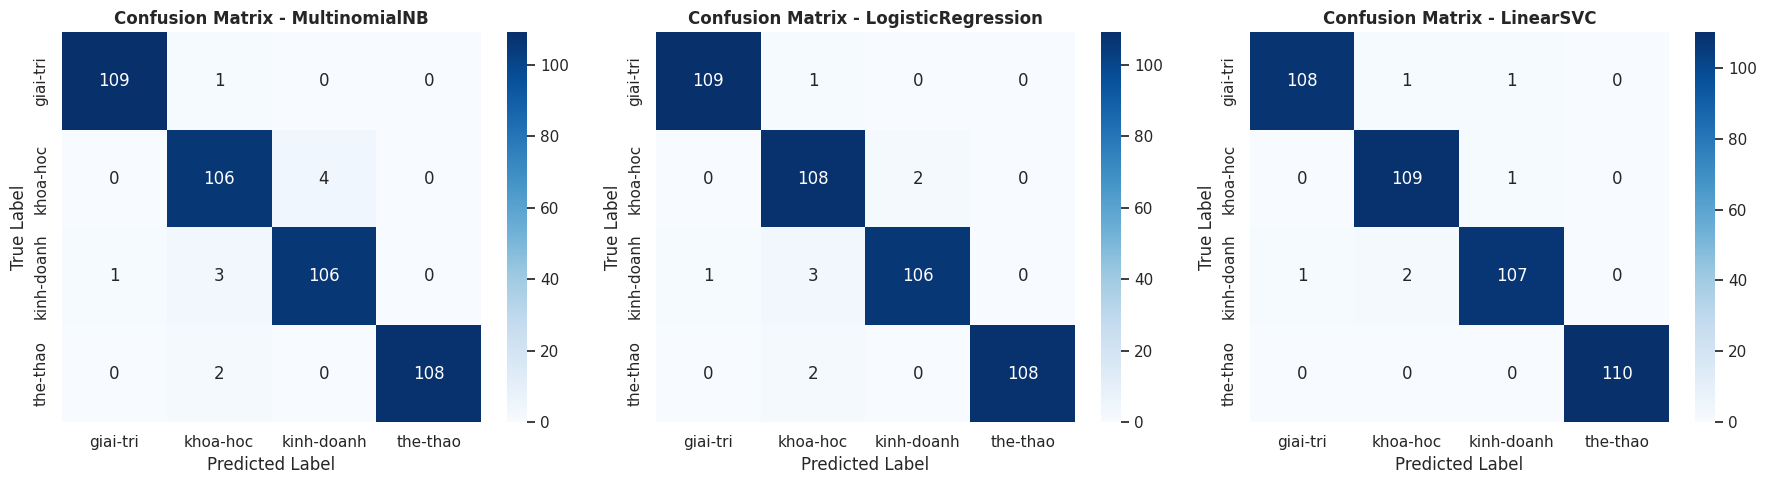

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# Reuse the 80/20 split from preprocessing (random_state=42, stratified).
models = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000, C=1.0),
    'LinearSVC': LinearSVC(dual='auto', C=1.0),
}

results = {}

for name, clf in models.items():
  pipe = Pipeline([
      (
          'tfidf',
          TfidfVectorizer(
              max_features=5000,
              ngram_range=(1, 2),
              stop_words=list(vietnamese_stopwords),
          ),
      ),
      ('classifier', clf),
  ])

  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  print(f'========== {name} ==========')
  print(classification_report(y_test, y_pred, digits=4))
  results[name] = {'pipeline': pipe, 'y_pred': y_pred}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories_labels = sorted(df['category'].unique())

for idx, name in enumerate(models.keys()):
    pred = results[name]['y_pred']
    cm = confusion_matrix(y_test, pred, labels=categories_labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=categories_labels,
        yticklabels=categories_labels,
        ax=axes[idx]
    )
    axes[idx].set_title(f'Confusion Matrix - {name}', fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

rows = []
for name in models:
  pred = results[name]['y_pred']
  acc = accuracy_score(y_test, pred)
  p, r, f1, _ = precision_recall_fscore_support(
      y_test, pred, average='macro', zero_division=0
  )
  rows.append(
      {
          'Model': name,
          'Accuracy': acc,
          'Macro Precision': p,
          'Macro Recall': r,
          'Macro F1': f1,
      }
  )
print('=== Model comparison (macro averages on the shared test split) ===')
print(pd.DataFrame(rows).round(4).to_string(index=False))

best = 'LinearSVC'
pred = results[best]['y_pred']
err = pd.DataFrame(
    {
        'text': X_test.to_numpy(),
        'true': y_test.to_numpy(),
        'pred': pred,
    }
)
err = err[err['true'] != err['pred']]
print(f'\nMisclassified articles ({best}): {len(err)} / {len(y_test)}')
for _, row in err.head(8).iterrows():
  snippet = ' '.join(str(row['text']).split()[:40])
  print(f"true={row['true']} pred={row['pred']}\n{snippet}\n")

## Limitations and conclusion

- **Source:** VnExpress only. Editorial style and section names may not match other publishers.
- **License:** Public pages used for this course. The notebook does not establish a right to republish the CSV.
- **Manual stopwords** may drop useful tokens or keep function words.
- **Numbers and capitalization** are removed for TF-IDF even though EDA uses them.
- **TF-IDF** is lexical; no PhoBERT/BERT comparison.
- **No validation split and no hyperparameter search** (`C=1.0`, default NB).
- **Class-level bigrams and the cosine matrix** are fit on the full corpus; they are exploratory, not the train-only classification vectorizer.
- **Error snippets** above depend on re-running this cell; stored outputs previously had only confusion matrices.

**Conclusion:** After Vietnamese segmentation and stopword removal, the four desks are linearly separable with unigram+bigram TF-IDF. LinearSVC is strongest on the 440-article test fold; remaining errors concentrate on science vs business, which also has the highest cross-class cosine similarity.